<a href="https://colab.research.google.com/github/paulahruizpro-ux/Alura-Store-Challenge/blob/main/TelecomX_BR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracão

In [203]:
import pandas as pd

In [204]:
import numpy as np

In [205]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [206]:
dados = pd.read_json('/content/drive/MyDrive/Dados Telecom 1/TelecomX_Data.json')

#🔧 Transformação

In [207]:
dados.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [208]:
dados.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [209]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [210]:
import json

# Ler como JSON
with open('/content/drive/MyDrive/Dados Telecom 1/TelecomX_Data.json', 'r') as f:
    dados_json = json.load(f)

# Normalizar o df
df_normalizado = pd.json_normalize(dados_json, sep='_')
df_normalizado

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [211]:
for col in df_normalizado.columns:
  unicos = df_normalizado[col].unique()
  print(f"---Coluna '{col}': ---")
  print(f"valores únicos -> {unicos}")
  print('\n')

---Coluna 'customerID': ---
valores únicos -> ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']


---Coluna 'Churn': ---
valores únicos -> ['No' 'Yes' '']


---Coluna 'customer_gender': ---
valores únicos -> ['Female' 'Male']


---Coluna 'customer_SeniorCitizen': ---
valores únicos -> [0 1]


---Coluna 'customer_Partner': ---
valores únicos -> ['Yes' 'No']


---Coluna 'customer_Dependents': ---
valores únicos -> ['Yes' 'No']


---Coluna 'customer_tenure': ---
valores únicos -> [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]


---Coluna 'phone_PhoneService': ---
valores únicos -> ['Yes' 'No']


---Coluna 'phone_MultipleLines': ---
valores únicos -> ['No' 'Yes' 'No phone service']


---Coluna 'internet_InternetService': ---
valores únicos -> ['DSL' 'Fiber optic' 'No']


---Coluna 

In [212]:
#Detectar valores vazios '' na coluna Churn
print((df_normalizado['Churn'] == '').sum())

224


In [213]:
df_normalizado = df_normalizado.replace({'': pd.NA})
print(df_normalizado['Churn'].isna().sum())

224


In [214]:
print('Linhas vazias no Churn:', (df_normalizado['Churn'] == '').sum())

Linhas vazias no Churn: 0


In [215]:
#Detectar valores na
print(df_normalizado.isna().any())

customerID                   False
Churn                         True
customer_gender              False
customer_SeniorCitizen       False
customer_Partner             False
customer_Dependents          False
customer_tenure              False
phone_PhoneService           False
phone_MultipleLines          False
internet_InternetService     False
internet_OnlineSecurity      False
internet_OnlineBackup        False
internet_DeviceProtection    False
internet_TechSupport         False
internet_StreamingTV         False
internet_StreamingMovies     False
account_Contract             False
account_PaperlessBilling     False
account_PaymentMethod        False
account_Charges_Monthly      False
account_Charges_Total        False
dtype: bool


In [216]:
#Detectar valores nulos
df_normalizado.isnull().sum()

,0
customerID,0
Churn,224
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [217]:
#Encontrar valores duplicados
duplicados = df_normalizado[df_normalizado.duplicated()]
duplicados

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total


In [218]:
df_normalizado.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [219]:
#Ver os tipos de dados de cada coluna
df_normalizado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [220]:
print((df_normalizado['account_Charges_Total'] == " ").sum())

11


In [221]:
#Modificar tipo de dado da coluna account_Charges_Total
df_normalizado['account_Charges_Total'] = pd.to_numeric(df_normalizado['account_Charges_Total'].astype(str).str.strip(),
                                                        errors = 'coerce')

In [222]:
#Modificar tipo de dado da coluna account_Charges_Total
df_normalizado['account_Charges_Total'] = df_normalizado['account_Charges_Total'].astype(np.float64)

In [223]:
import re

def adicionar_underscore(nome_coluna):
    # Insere _ antes de maiúsculas e coloca tudo em minúsculas
    nome = re.sub(r'([a-z])([A-Z])', r'\1_\2', str(nome_coluna)).lower()
    return nome.strip('_')

# Aplica em TODAS as colunas
df_normalizado.columns = [adicionar_underscore(col) for col in df_normalizado.columns]

df_normalizado

,customer_id,churn,customer_gender,customer_senior_citizen,customer_partner,customer_dependents,customer_tenure,phone_phone_service,phone_multiple_lines,internet_internet_service,...,internet_online_backup,internet_device_protection,internet_tech_support,internet_streaming_tv,internet_streaming_movies,account_contract,account_paperless_billing,account_payment_method,account_charges_monthly,account_charges_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7263,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7264,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


#📊 Carga e análise

In [225]:
df_normalizado.describe()

,customer_senior_citizen,customer_tenure,account_charges_monthly,account_charges_total
count,7267.000000,7267.000000,7267.000000,7256.000000
mean,0.162653,32.346498,64.720098,2280.634213
std,0.369074,24.571773,30.129572,2268.632997
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.425000,400.225000
50%,0.000000,29.000000,70.300000,1391.000000
75%,0.000000,55.000000,89.875000,3785.300000
max,1.000000,72.000000,118.750000,8684.800000


In [228]:
import matplotlib.pyplot as plt

In [245]:
#Retirar os NaN de Churn para executar o gráfico
df_plot = df_normalizado.dropna(subset=['churn'])

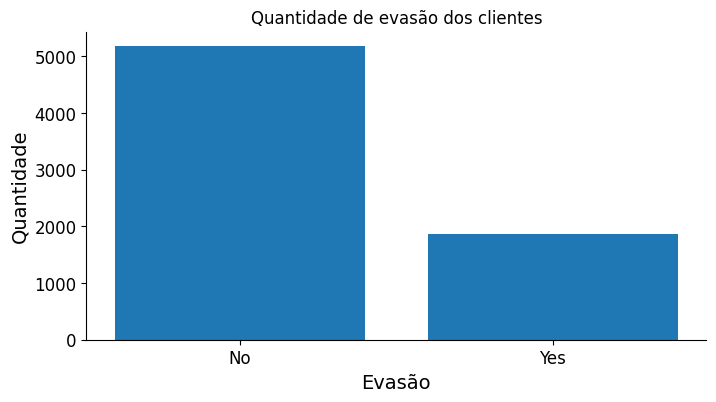

In [250]:
contagem = df_plot['churn'].value_counts()

fig, ax = plt.subplots(figsize =(8,4))
ax.bar(contagem.index, contagem.values)
ax.set_title('Quantidade de evasão dos clientes')
ax.set_xlabel('Evasão', fontsize = 14)
ax.set_ylabel('Quantidade', fontsize = 14)
ax.xaxis.set_tick_params(labelsize = 12)
ax.yaxis.set_tick_params(labelsize = 12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


#📄Relatorio Final

In [224]:
# Transformação


# Foram encontradas strings na coluna account charges total
# e foram usadas os metodos to numeric(), astype(str) para ler como str, str.strip para retirar os espaços
# foi usada também o np.floaot64 para transformar a coluna nesse tipo de dados